<a href="https://colab.research.google.com/github/pnhongngoc37-cloud/TH_DeepLearning/blob/main/Tuan2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ Tất cả thư viện đã được nạp thành công!
   TensorFlow version : 2.20.0
   PyTorch version    : 2.10.0+cpu
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

--- Đọc dữ liệu thành công ---
   STT   T1   L1   H1   S1   V1   X1   D1   N1   T2  ...   X6   D6   N6  GT  \
0    1  7.2  7.3  6.3  7.3  7.0  7.9  7.3  5.5  8.4  ...  6.6  7.6  5.9   F   
1    2  5.4  3.9  3.9  4.0  5.4  5.4  5.3  2.8  6.3  ...  6.6  6.1  4.4   M   
2    3  5.6  6.8  7.2  7.5  4.3  7.4  5.8  3.2  5.0  ...  7.9  8.1  4.6   M   

   DT   KV   DH1   DH2  DH3  KT  
0 NaN  2NT  3.25  3.25  4.5  A1  
1 NaN    1  6.00  4.00  3.5   C  
2 NaN    1  5.00  6.75  4.0   C  

[3 rows x 56 columns]

Kích thước dataset: (100, 56)

BƯỚC 1: CHUẨN BỊ VÀ LÀM SẠCH DỮ LIỆU
Số mẫu sau khi làm sạch: 100 (loại bỏ 0 hàng NaN)

Thống kê mô tả:
           T1      L1      H1     DH1
count  100.00  100.00  100.00  100.00
mean     5.95    5.82    6.28    3.74
std  

Model: "ANN_TensorFlow"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209 (836.00 B)

 Trainable params: 209 (836.00 B)

 Non-trainable params: 0 (0.00 B)


Bắt đầu huấn luyện TensorFlow...

TensorFlow ANN — MAE: 1.1250 | RMSE: 1.3606 | R²: -0.0951

BƯỚC 3C: ARTIFICIAL NEURAL NETWORK — PyTorch
Bắt đầu huấn luyện PyTorch...
Huấn luyện PyTorch hoàn tất!
PyTorch ANN     — MAE: 1.2169 | RMSE: 1.4271 | R²: -0.2048

BƯỚC 4: TỔNG HỢP KẾT QUẢ CÁC MÔ HÌNH
                    Mô hình      MAE     RMSE        R²
Linear Regression (sklearn) 1.214482 1.428294 -0.206779
       ANN TensorFlow/Keras 1.125000 1.360626 -0.095142
                ANN PyTorch 1.216864 1.427150 -0.204847

So sánh Thực tế vs Dự đoán (5 học sinh đầu tiên trong tập Test):
HS      Thực tế     Lin.Reg      TF ANN      PT ANN
---------------------------------------------------
1          1.75        3.80        3.54        3.85
2          1.00        3.79        3.55        3.84
3          2.25        3.86        3.54        3.84
4          2.00        3.89        3.99        3.86
5          3.75        3.86        3.54        3.80


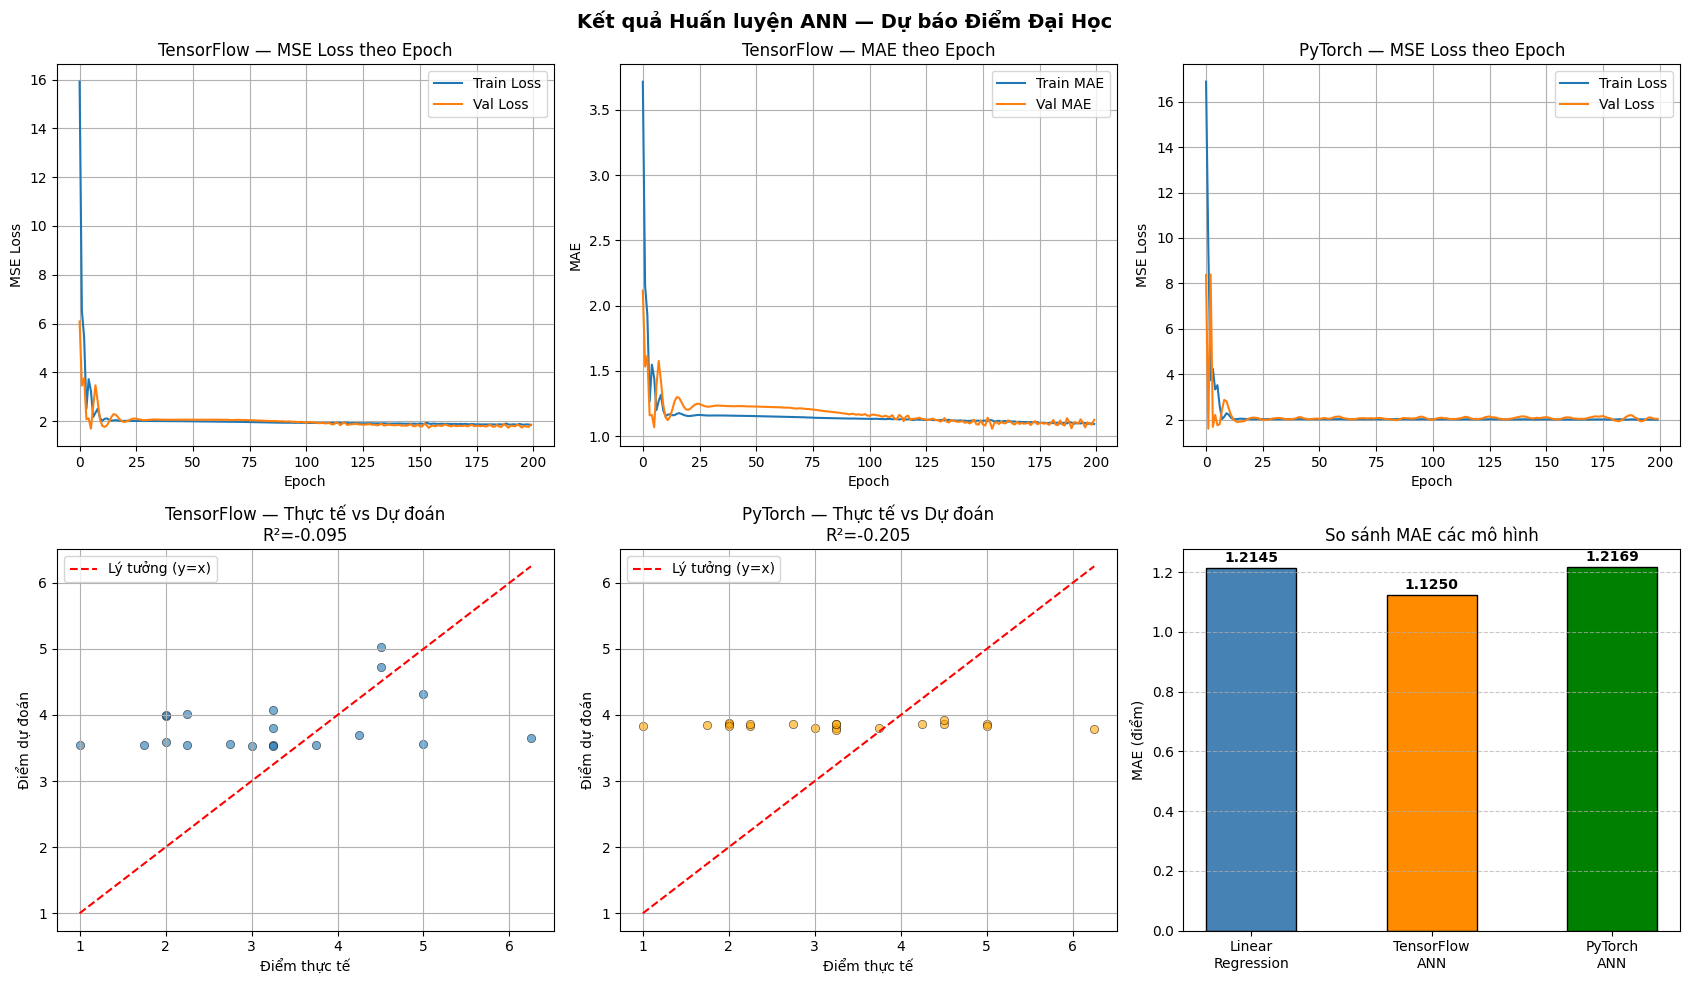

In [3]:
# ============================================================
# THỰC HÀNH ANN - DỰ BÁO ĐIỂM ĐẠI HỌC
# Bao gồm: Linear Regression (sklearn), TensorFlow, PyTorch
# Tác giả: Hoàn chỉnh theo yêu cầu thực hành
# ============================================================

# ==========================================
# BƯỚC 0: KẾT NỐI DRIVE VÀ KHAI BÁO THƯ VIỆN
# ==========================================
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# --- TensorFlow / Keras ---
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD

# --- Scikit-learn ---
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# --- PyTorch ---
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

print("✅ Tất cả thư viện đã được nạp thành công!")
print(f"   TensorFlow version : {tf.__version__}")
print(f"   PyTorch version    : {torch.__version__}")

# Kết nối Google Drive
drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/dulieuxettuyendaihoc.csv'
df = pd.read_csv(file_path)

print("\n--- Đọc dữ liệu thành công ---")
print(df.head(3))
print(f"\nKích thước dataset: {df.shape}")

# ==========================================
# BƯỚC 1: CHUẨN BỊ VÀ LÀM SẠCH DỮ LIỆU
# ==========================================
print("\n" + "="*50)
print("BƯỚC 1: CHUẨN BỊ VÀ LÀM SẠCH DỮ LIỆU")
print("="*50)

# Biến độc lập: Điểm Toán, Lý, Hóa học kỳ 1 lớp 10
features = ['T1', 'L1', 'H1']
# Biến phụ thuộc: Điểm thi Đại học môn 1
target   = 'DH1'

# Loại bỏ hàng có giá trị khuyết thiếu
df_clean = df[features + [target]].dropna()
print(f"Số mẫu sau khi làm sạch: {len(df_clean)} (loại bỏ {len(df) - len(df_clean)} hàng NaN)")

X = df_clean[features].values.astype(np.float32)
y = df_clean[target].values.astype(np.float32)

# ── Thống kê mô tả cơ bản ──
print("\nThống kê mô tả:")
print(df_clean.describe().round(2))

# ── Chia tập Train / Test (80/20) TRƯỚC khi chuẩn hóa (chống data leakage) ──
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\nKích thước tập Train : {X_train.shape}")
print(f"Kích thước tập Test  : {X_test.shape}")

# ==========================================
# BƯỚC 2: CHUẨN HÓA DỮ LIỆU (MinMaxScaler)
# ==========================================
print("\n" + "="*50)
print("BƯỚC 2: CHUẨN HÓA DỮ LIỆU")
print("="*50)

scaler = MinMaxScaler()

# CHỈ fit trên tập Train, rồi transform cả hai tập
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)   # ← KHÔNG fit lại để tránh data leakage

print("Chuẩn hóa Min-Max hoàn tất (fit chỉ trên tập Train)")
print(f"  Min học được: {scaler.data_min_}")
print(f"  Max học được: {scaler.data_max_}")

# ==========================================
# BƯỚC 3A: LINEAR REGRESSION (sklearn) - Baseline
# ==========================================
print("\n" + "="*50)
print("BƯỚC 3A: LINEAR REGRESSION (sklearn) — Baseline")
print("="*50)

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)
mae_lr  = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr   = r2_score(y_test, y_pred_lr)

print(f"Linear Regression — MAE: {mae_lr:.4f} | RMSE: {rmse_lr:.4f} | R²: {r2_lr:.4f}")
print(f"Hệ số hồi quy (w): {lr_model.coef_}")
print(f"Hệ số chệch    (b): {lr_model.intercept_:.4f}")

# ==========================================
# BƯỚC 3B: HUẤN LUYỆN MÔ HÌNH TENSORFLOW / KERAS
# ==========================================
print("\n" + "="*50)
print("BƯỚC 3B: ARTIFICIAL NEURAL NETWORK — TensorFlow/Keras")
print("="*50)

tf.random.set_seed(42)

model_tf = Sequential([
    # Lớp ẩn 1: 16 neuron, ReLU, nhận 3 đặc trưng đầu vào
    Dense(units=16, input_dim=X_train_scaled.shape[1],
          kernel_initializer='glorot_uniform', activation='relu'),
    # Lớp ẩn 2: 8 neuron, ReLU
    Dense(units=8, kernel_initializer='glorot_uniform', activation='relu'),
    # Lớp đầu ra: 1 neuron, linear (hồi quy)
    Dense(units=1, kernel_initializer='glorot_uniform', activation=None)
], name="ANN_TensorFlow")

# Dùng SGD (Stochastic Gradient Descent) như yêu cầu bài lab
model_tf.compile(
    optimizer=SGD(learning_rate=0.01, momentum=0.9),
    loss='mse',
    metrics=['mae']
)

model_tf.summary()

print("\nBắt đầu huấn luyện TensorFlow...")
history_tf = model_tf.fit(
    X_train_scaled, y_train,
    epochs=200,
    batch_size=32,
    validation_data=(X_test_scaled, y_test),
    verbose=0   # tắt log từng epoch cho gọn; đổi thành 1 nếu muốn xem
)

# ── Đánh giá TensorFlow ──
loss_tf, mae_tf = model_tf.evaluate(X_test_scaled, y_test, verbose=0)
y_pred_tf = model_tf.predict(X_test_scaled, verbose=0).flatten()
rmse_tf = np.sqrt(mean_squared_error(y_test, y_pred_tf))
r2_tf   = r2_score(y_test, y_pred_tf)

print(f"\nTensorFlow ANN — MAE: {mae_tf:.4f} | RMSE: {rmse_tf:.4f} | R²: {r2_tf:.4f}")

# ==========================================
# BƯỚC 3C: HUẤN LUYỆN MÔ HÌNH PYTORCH
# ==========================================
print("\n" + "="*50)
print("BƯỚC 3C: ARTIFICIAL NEURAL NETWORK — PyTorch")
print("="*50)

# Chuyển sang Tensor
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train,        dtype=torch.float32).unsqueeze(1)
X_test_t  = torch.tensor(X_test_scaled,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test,         dtype=torch.float32).unsqueeze(1)

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader  = DataLoader(train_dataset, batch_size=32, shuffle=True)

# Định nghĩa kiến trúc ANN
class ANNRegressor(nn.Module):
    def __init__(self, input_dim):
        super(ANNRegressor, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 1)
        )

    def forward(self, x):
        return self.net(x)

torch.manual_seed(42)
model_pt = ANNRegressor(input_dim=X_train_scaled.shape[1])

# SGD với momentum tương tự TensorFlow
optimizer_pt = optim.SGD(model_pt.parameters(), lr=0.01, momentum=0.9)
criterion_pt = nn.MSELoss()

# ── Vòng lặp huấn luyện PyTorch ──
EPOCHS = 200
train_losses_pt = []
val_losses_pt   = []

print("Bắt đầu huấn luyện PyTorch...")
for epoch in range(1, EPOCHS + 1):
    model_pt.train()
    epoch_loss = 0.0
    for X_batch, y_batch in train_loader:
        optimizer_pt.zero_grad()
        y_hat = model_pt(X_batch)
        loss  = criterion_pt(y_hat, y_batch)
        loss.backward()
        optimizer_pt.step()
        epoch_loss += loss.item() * len(X_batch)

    train_losses_pt.append(epoch_loss / len(train_dataset))

    # Validation (không cập nhật gradient)
    model_pt.eval()
    with torch.no_grad():
        val_loss = criterion_pt(model_pt(X_test_t), y_test_t).item()
    val_losses_pt.append(val_loss)

print("Huấn luyện PyTorch hoàn tất!")

# ── Đánh giá PyTorch ──
model_pt.eval()
with torch.no_grad():
    y_pred_pt = model_pt(X_test_t).squeeze().numpy()

mae_pt  = mean_absolute_error(y_test, y_pred_pt)
rmse_pt = np.sqrt(mean_squared_error(y_test, y_pred_pt))
r2_pt   = r2_score(y_test, y_pred_pt)

print(f"PyTorch ANN     — MAE: {mae_pt:.4f} | RMSE: {rmse_pt:.4f} | R²: {r2_pt:.4f}")

# ==========================================
# BƯỚC 4: ĐÁNH GIÁ VÀ SO SÁNH CÁC MÔ HÌNH
# ==========================================
print("\n" + "="*50)
print("BƯỚC 4: TỔNG HỢP KẾT QUẢ CÁC MÔ HÌNH")
print("="*50)

results = pd.DataFrame({
    'Mô hình' : ['Linear Regression (sklearn)', 'ANN TensorFlow/Keras', 'ANN PyTorch'],
    'MAE'     : [mae_lr,  mae_tf,  mae_pt],
    'RMSE'    : [rmse_lr, rmse_tf, rmse_pt],
    'R²'      : [r2_lr,   r2_tf,   r2_pt],
})
print(results.to_string(index=False))

# ── Dự đoán 5 học sinh đầu tiên trong tập Test ──
print("\nSo sánh Thực tế vs Dự đoán (5 học sinh đầu tiên trong tập Test):")
print(f"{'HS':<5}{'Thực tế':>10}{'Lin.Reg':>12}{'TF ANN':>12}{'PT ANN':>12}")
print("-" * 51)
for i in range(5):
    print(f"{i+1:<5}{y_test[i]:>10.2f}{y_pred_lr[i]:>12.2f}"
          f"{y_pred_tf[i]:>12.2f}{y_pred_pt[i]:>12.2f}")

# ==========================================
# BƯỚC 5: TRỰC QUAN HÓA KẾT QUẢ
# ==========================================
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle("Kết quả Huấn luyện ANN — Dự báo Điểm Đại Học", fontsize=14, fontweight='bold')

# ── (1) Loss TensorFlow ──
ax = axes[0, 0]
ax.plot(history_tf.history['loss'],     label='Train Loss')
ax.plot(history_tf.history['val_loss'], label='Val Loss')
ax.set_title('TensorFlow — MSE Loss theo Epoch')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
ax.legend(); ax.grid(True)

# ── (2) MAE TensorFlow ──
ax = axes[0, 1]
ax.plot(history_tf.history['mae'],     label='Train MAE')
ax.plot(history_tf.history['val_mae'], label='Val MAE')
ax.set_title('TensorFlow — MAE theo Epoch')
ax.set_xlabel('Epoch'); ax.set_ylabel('MAE')
ax.legend(); ax.grid(True)

# ── (3) Loss PyTorch ──
ax = axes[0, 2]
ax.plot(train_losses_pt, label='Train Loss')
ax.plot(val_losses_pt,   label='Val Loss')
ax.set_title('PyTorch — MSE Loss theo Epoch')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
ax.legend(); ax.grid(True)

# ── (4) Scatter: Thực tế vs Dự đoán (TF) ──
ax = axes[1, 0]
ax.scatter(y_test, y_pred_tf, alpha=0.6, edgecolors='k', linewidths=0.5)
mn, mx = y_test.min(), y_test.max()
ax.plot([mn, mx], [mn, mx], 'r--', label='Lý tưởng (y=x)')
ax.set_title(f'TensorFlow — Thực tế vs Dự đoán\nR²={r2_tf:.3f}')
ax.set_xlabel('Điểm thực tế'); ax.set_ylabel('Điểm dự đoán')
ax.legend(); ax.grid(True)

# ── (5) Scatter: Thực tế vs Dự đoán (PyTorch) ──
ax = axes[1, 1]
ax.scatter(y_test, y_pred_pt, alpha=0.6, color='orange', edgecolors='k', linewidths=0.5)
ax.plot([mn, mx], [mn, mx], 'r--', label='Lý tưởng (y=x)')
ax.set_title(f'PyTorch — Thực tế vs Dự đoán\nR²={r2_pt:.3f}')
ax.set_xlabel('Điểm thực tế'); ax.set_ylabel('Điểm dự đoán')
ax.legend(); ax.grid(True)

# ── (6) So sánh MAE 3 mô hình ──
ax = axes[1, 2]
model_names = ['Linear\nRegression', 'TensorFlow\nANN', 'PyTorch\nANN']
maes = [mae_lr, mae_tf, mae_pt]
colors = ['steelblue', 'darkorange', 'green']
bars = ax.bar(model_names, maes, color=colors, edgecolor='black', width=0.5)
for bar, val in zip(bars, maes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.4f}', ha='center', va='bottom', fontweight='bold')
ax.set_title('So sánh MAE các mô hình')
ax.set_ylabel('MAE (điểm)')
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()